# Dense periodic n=1: Granger causality and TDMI

This notebook completes the first stage of Linus's exercise for the dense periodic $n=1$ reference model. It asks whether the binary event indicator Granger-predicts volatility and whether their signed-lag mutual information is consistent with the known event-leading timing. Both directions are examined; volatility-leading results are a false-reverse-edge diagnostic.

## 2. Scope and interpretation

The known structural graph is E_i -> omega_(i+1) -> sigma_(i+1). Granger causality is an incremental linear predictive test, and TDMI is a nonlinear lagged-dependence measure; neither alone proves structural causality. This notebook does not estimate weights, forecast, analyse real data, or implement later-stage methods.

## 3. Imports

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests

pd.set_option('display.precision', 6)

## 4. Load Notebook 00 silently

The core notebook is executed silently so that its reusable functions and reference configuration enter this namespace without reproducing its plots or printed validation output. No simulator or core functional form is redefined below.

In [2]:
%%capture
%run "./00_model_specification_and_core_simulator.ipynb"

## 5. Reconstruct the dense periodic n=1 reference path

The new path uses the imported simulation engine and the imported reference configuration. Event times end at the final transition source time, not the terminal state time.

In [3]:
required_core_names = {
    'simulate_event_volatility', 'alpha_fn', 'nu_fn', 'rho_fn',
    'event_weight_fn', 'periodic_event_times', 'reference_config'
}
assert required_core_names.issubset(globals())

model_params = reference_config['model']
event_params = reference_config['events']
simulation_params = reference_config['simulation']
expected_period = 21 / 252
assert model_params['n'] == 1
assert np.isclose(event_params['period'], expected_period)

steps_per_year = simulation_params['trading_steps_per_year']
n_steps = simulation_params['years'] * steps_per_year
time_grid = np.arange(n_steps + 1, dtype=float) / steps_per_year
event_times = periodic_event_times(time_grid[0], time_grid[-2], event_params)
dense_result = simulate_event_volatility(
    time_grid=time_grid,
    S0=simulation_params['S0'],
    sigma0=simulation_params['sigma0'],
    n=model_params['n'],
    alpha_fn=alpha_fn,
    nu_fn=nu_fn,
    rho_fn=rho_fn,
    event_weight_fn=event_weight_fn,
    model_params=model_params,
    event_times=event_times,
    event_params=event_params,
    seed=simulation_params['seed'],
)

states = dense_result['states']
transitions = dense_result['transitions']
states_snapshot = states.copy(deep=True)
transitions_snapshot = transitions.copy(deep=True)
print(f'n = {model_params["n"]}; event period = {event_params["period"]:.8f} years ({event_params["period"] * steps_per_year:.0f} trading steps)')
print(f'Generated exact event times: {len(event_times)}')

n = 1; event period = 0.08333333 years (21 trading steps)
Generated exact event times: 23


## 6. Build and validate the aligned analysis table

The primary state-indexed series pair is sigma_t = sigma_i and E_t = E_i. Both refer to source time t_i. Because the event affects the transition into the next state, an event-leading effect is expected at positive delay, E_t -> sigma_(t+1); `sigma_next` is retained only as a descriptive transition outcome.

In [4]:
analysis_table = pd.DataFrame({
    't': transitions['t'].to_numpy(),
    'sigma_t': states.iloc[:-1]['sigma'].to_numpy(),
    'event_t': transitions['event'].to_numpy(),
    'sigma_next': transitions['sigma_next'].to_numpy(),
    'omega_next': transitions['omega_next'].to_numpy(),
})
analysis_table['delta_sigma_next'] = analysis_table['sigma_next'] - analysis_table['sigma_t']
analysis_table['active_event_response'] = analysis_table['omega_next'] > 1.0

assert len(analysis_table) == len(transitions)
np.testing.assert_allclose(analysis_table['sigma_t'], states.iloc[:-1]['sigma'])
np.testing.assert_allclose(analysis_table['sigma_next'], transitions['sigma_next'])
assert set(analysis_table['event_t'].unique()).issubset({0, 1})
assert analysis_table[['sigma_t', 'event_t']].notna().all().all()
assert len(event_times) == int(analysis_table['event_t'].sum())
event_indices = np.flatnonzero(analysis_table['event_t'].to_numpy() == 1)
assert np.all(np.diff(event_indices) == 21)
assert event_params['response_horizon'] < event_params['period']

event_fraction = float(analysis_table['event_t'].mean())
active_response_fraction = float(analysis_table['active_event_response'].mean())
print(f'Event-indicator fraction: {event_fraction:.6f}')
print(f'Active-weight transition fraction: {active_response_fraction:.6f}')
analysis_table.head()

Event-indicator fraction: 0.045635
Active-weight transition fraction: 0.593254


,t,sigma_t,event_t,sigma_next,omega_next,delta_sigma_next,active_event_response
0,0.000000,0.200000,0,0.199041,1.0,-0.000959,False
1,0.003968,0.199041,0,0.197175,1.0,-0.001866,False
2,0.007937,0.197175,0,0.196176,1.0,-0.000999,False
3,0.011905,0.196176,0,0.197132,1.0,0.000956,False
4,0.015873,0.197132,0,0.195876,1.0,-0.001256,False


## 7. Descriptive event-effect check

This comparison describes the simulated association between a source-time event and the following volatility change. It is not a causal test because it does not condition on history or distinguish periodic-calendar predictability.

          count      mean       std    median
event_t                                      
No event    481  0.000074  0.001021  0.000166
Event        23  0.000842  0.001085  0.000899


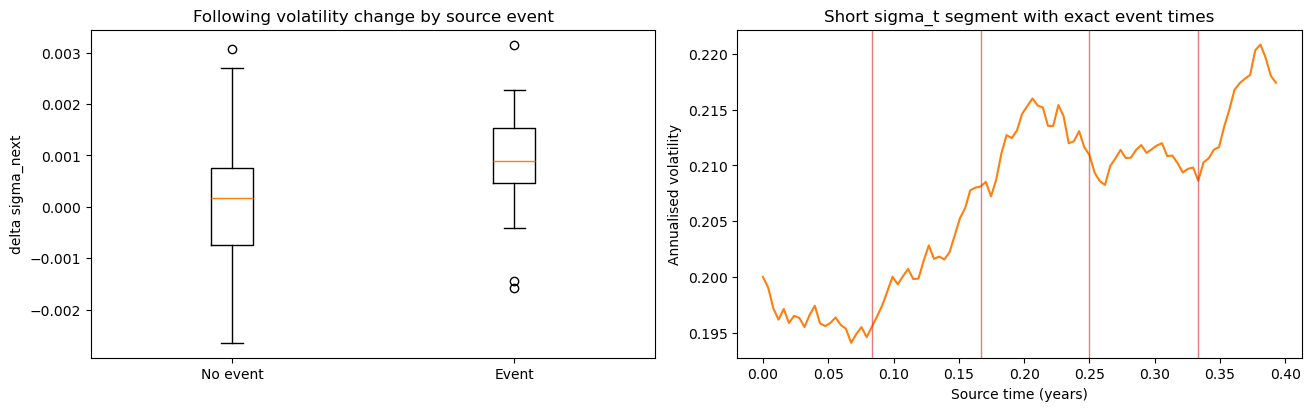

In [5]:
event_effect_summary = (
    analysis_table.groupby('event_t')['delta_sigma_next']
    .agg(['count', 'mean', 'std', 'median'])
    .rename(index={0: 'No event', 1: 'Event'})
)
print(event_effect_summary)

segment_end = min(100, len(analysis_table))
segment = analysis_table.iloc[:segment_end]
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
axes[0].boxplot(
    [
        analysis_table.loc[analysis_table['event_t'].eq(0), 'delta_sigma_next'],
        analysis_table.loc[analysis_table['event_t'].eq(1), 'delta_sigma_next'],
    ],
    tick_labels=['No event', 'Event'],
)
axes[0].set(title='Following volatility change by source event', ylabel='delta sigma_next')
axes[1].plot(segment['t'], segment['sigma_t'], color='tab:orange')
for event_time in segment.loc[segment['event_t'].eq(1), 't']:
    axes[1].axvline(event_time, color='tab:red', alpha=0.6, linewidth=1)
axes[1].set(title='Short sigma_t segment with exact event times', xlabel='Source time (years)', ylabel='Annualised volatility')
plt.show()

## 8. Granger-causality methodology

For target $y_t$ and candidate driver $x_t$, the restricted regression contains a constant and $p$ historical target lags. The unrestricted regression additionally contains the same $p$ historical driver lags. The null is that all driver-lag coefficients are zero. With $N$ effective observations, the nested-regression statistic is $F=((RSS_r-RSS_u)/p)/(RSS_u/(N-2p-1))$, and its upper-tail p-value uses `scipy.stats.f.sf`. `log_variance_ratio = log(RSS_r/RSS_u)` summarizes the incremental fit.

## 9. Manual nested-regression F-test

In [6]:
def granger_f_test(target, driver, lag):
    target = np.asarray(target, dtype=float)
    driver = np.asarray(driver, dtype=float)
    if target.ndim != 1 or driver.ndim != 1 or target.size != driver.size:
        raise ValueError('target and driver must be equal-length one-dimensional arrays.')
    if lag < 1 or target.size <= 2 * lag + 1:
        raise ValueError('lag leaves insufficient observations for the unrestricted regression.')

    n_obs = target.size - lag
    response = target[lag:]
    target_lags = np.column_stack([target[lag - j: target.size - j] for j in range(1, lag + 1)])
    driver_lags = np.column_stack([driver[lag - j: driver.size - j] for j in range(1, lag + 1)])
    restricted = sm.OLS(response, sm.add_constant(target_lags, has_constant='add')).fit()
    unrestricted = sm.OLS(
        response, sm.add_constant(np.column_stack([target_lags, driver_lags]), has_constant='add')
    ).fit()

    rss_restricted = float(restricted.ssr)
    rss_unrestricted = float(unrestricted.ssr)
    residual_df = int(unrestricted.df_resid)
    if rss_unrestricted > rss_restricted + 1e-10:
        raise AssertionError('Unrestricted RSS exceeds restricted RSS beyond numerical tolerance.')
    if residual_df <= 0:
        raise AssertionError('Unrestricted regression has non-positive residual degrees of freedom.')

    f_stat = ((rss_restricted - rss_unrestricted) / lag) / (rss_unrestricted / residual_df)
    p_value = float(stats.f.sf(f_stat, lag, residual_df))
    return {
        'lag': lag,
        'n_obs': n_obs,
        'rss_restricted': rss_restricted,
        'rss_unrestricted': rss_unrestricted,
        'f_stat': float(f_stat),
        'p_value': p_value,
        'residual_df': residual_df,
        'log_variance_ratio': float(np.log(rss_restricted / rss_unrestricted)),
    }


def granger_results_table(target, driver, max_lag):
    return pd.DataFrame([granger_f_test(target, driver, lag) for lag in range(1, max_lag + 1)])


sigma_t = analysis_table['sigma_t'].to_numpy()
event_t = analysis_table['event_t'].to_numpy(dtype=float)
max_lag = 20
direct_timing_lag = 1
response_window_lag = 13

# Each design row at source index i uses only columns indexed i-j, where j is at least one.
for lag in range(1, max_lag + 1):
    current_indices = np.arange(lag, len(sigma_t))
    historical_indices = np.column_stack([np.arange(lag - j, len(sigma_t) - j) for j in range(1, lag + 1)])
    assert np.all(historical_indices < current_indices[:, None])

## 10. Granger results: event -> volatility

Here the target is sigma_t and the driver is E_t. Rejection means that historical events Granger-predict source-indexed volatility after its own lagged history is included. Lag 13 is pre-specified because the weight is active on the event transition and the following 12 transitions; the complete scan is exploratory sensitivity analysis.

Direct one-step timing check (p = 1):
lag                                     1
n_obs                                 503
rss_restricted                   0.000537
rss_unrestricted                 0.000524
f_stat                          12.094457
p_value                           0.00055
residual_df                           500
log_variance_ratio               0.023901
direction             event -> volatility
Full event-response-window lag order (p = 13):
lag                                    13
n_obs                                 491
rss_restricted                   0.000494
rss_unrestricted                 0.000442
f_stat                           4.190183
p_value                          0.000001
residual_df                           464
log_variance_ratio               0.111002
direction             event -> volatility


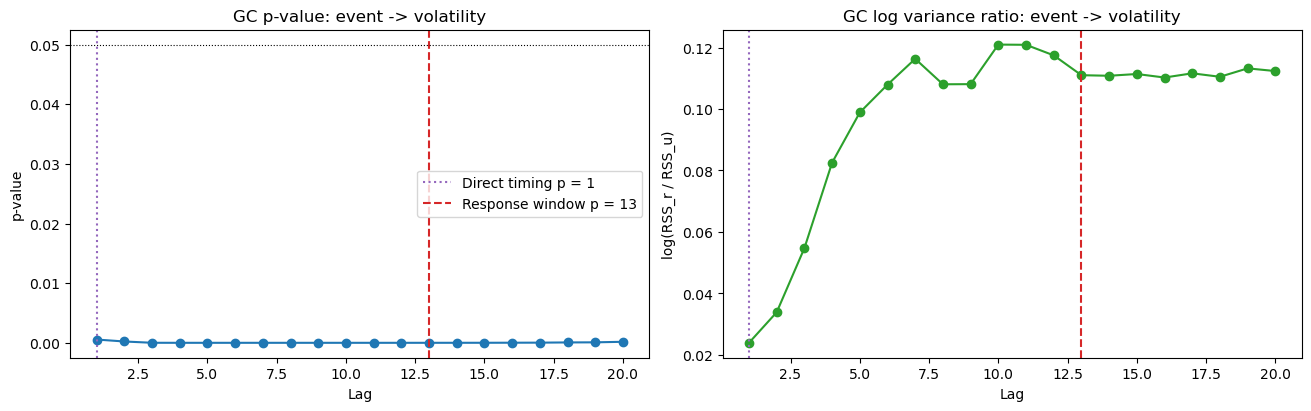

In [7]:
gc_event_to_sigma = granger_results_table(sigma_t, event_t, max_lag)
gc_event_to_sigma['direction'] = 'event -> volatility'
gc_event_to_sigma_p1 = gc_event_to_sigma.loc[gc_event_to_sigma['lag'].eq(direct_timing_lag)].iloc[0]
gc_event_to_sigma_p13 = gc_event_to_sigma.loc[gc_event_to_sigma['lag'].eq(response_window_lag)].iloc[0]
print('Direct one-step timing check (p = 1):')
print(gc_event_to_sigma_p1.to_string())
print('Full event-response-window lag order (p = 13):')
print(gc_event_to_sigma_p13.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
axes[0].plot(gc_event_to_sigma['lag'], gc_event_to_sigma['p_value'], marker='o')
axes[0].axvline(direct_timing_lag, color='tab:purple', linestyle=':', label='Direct timing p = 1')
axes[0].axvline(response_window_lag, color='tab:red', linestyle='--', label='Response window p = 13')
axes[0].axhline(0.05, color='black', linewidth=0.8, linestyle=':')
axes[0].set(title='GC p-value: event -> volatility', xlabel='Lag', ylabel='p-value')
axes[0].legend()
axes[1].plot(gc_event_to_sigma['lag'], gc_event_to_sigma['log_variance_ratio'], marker='o', color='tab:green')
axes[1].axvline(direct_timing_lag, color='tab:purple', linestyle=':')
axes[1].axvline(response_window_lag, color='tab:red', linestyle='--')
axes[1].set(title='GC log variance ratio: event -> volatility', xlabel='Lag', ylabel='log(RSS_r / RSS_u)')
plt.show()

## 11. Granger results: volatility -> event

Here the binary event indicator is the target. This uses the same linear nested-regression statistic as a predictive diagnostic, not a probability model. The structural generator has no sigma -> E edge, so a reverse result may reflect deterministic periodicity and calendar-phase predictability.

Direct one-step timing check (p = 1):
lag                                     1
n_obs                                 503
rss_restricted                  21.897917
rss_unrestricted                21.891076
f_stat                           0.156245
p_value                          0.692806
residual_df                           500
log_variance_ratio               0.000312
direction             volatility -> event
Full event-response-window lag order (p = 13):
lag                                    13
n_obs                                 491
rss_restricted                  20.244792
rss_unrestricted                19.605432
f_stat                           1.163975
p_value                          0.303267
residual_df                           464
log_variance_ratio               0.032091
direction             volatility -> event


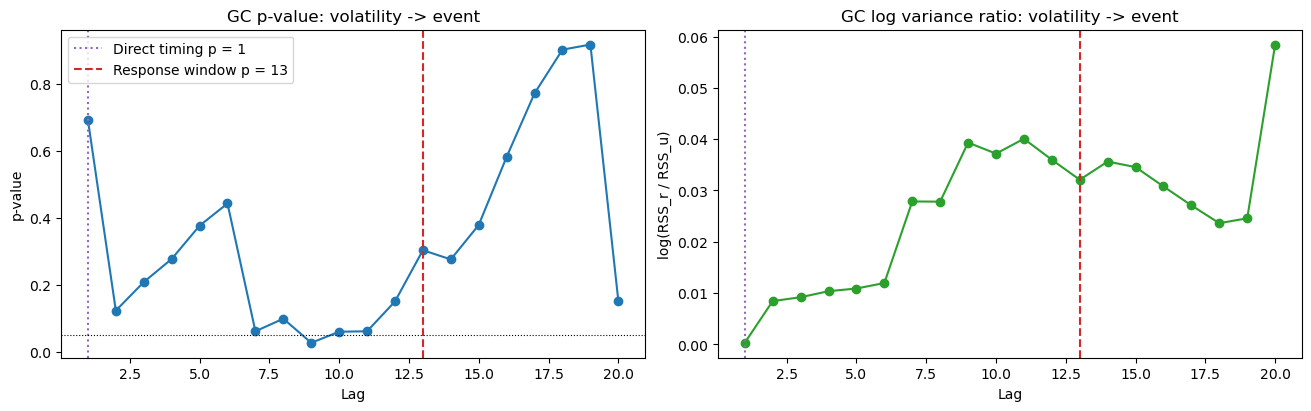

In [8]:
gc_sigma_to_event = granger_results_table(event_t, sigma_t, max_lag)
gc_sigma_to_event['direction'] = 'volatility -> event'
gc_sigma_to_event_p1 = gc_sigma_to_event.loc[gc_sigma_to_event['lag'].eq(direct_timing_lag)].iloc[0]
gc_sigma_to_event_p13 = gc_sigma_to_event.loc[gc_sigma_to_event['lag'].eq(response_window_lag)].iloc[0]
print('Direct one-step timing check (p = 1):')
print(gc_sigma_to_event_p1.to_string())
print('Full event-response-window lag order (p = 13):')
print(gc_sigma_to_event_p13.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
axes[0].plot(gc_sigma_to_event['lag'], gc_sigma_to_event['p_value'], marker='o')
axes[0].axvline(direct_timing_lag, color='tab:purple', linestyle=':', label='Direct timing p = 1')
axes[0].axvline(response_window_lag, color='tab:red', linestyle='--', label='Response window p = 13')
axes[0].axhline(0.05, color='black', linewidth=0.8, linestyle=':')
axes[0].set(title='GC p-value: volatility -> event', xlabel='Lag', ylabel='p-value')
axes[0].legend()
axes[1].plot(gc_sigma_to_event['lag'], gc_sigma_to_event['log_variance_ratio'], marker='o', color='tab:green')
axes[1].axvline(direct_timing_lag, color='tab:purple', linestyle=':')
axes[1].axvline(response_window_lag, color='tab:red', linestyle='--')
axes[1].set(title='GC log variance ratio: volatility -> event', xlabel='Lag', ylabel='log(RSS_r / RSS_u)')
plt.show()

## 12. Statsmodels Granger cross-check

`grangercausalitytests` tests whether its second column Granger-causes its first. The same column order is therefore used as the manual target-driver tests. The F-statistics and p-values at the primary lag must agree up to numerical tolerance.

In [9]:
def statsmodels_gc_at_lag(target, driver, lag):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', FutureWarning)
        result = grangercausalitytests(np.column_stack([target, driver]), maxlag=[lag], verbose=False)
    f_stat, p_value, residual_df, numerator_df = result[lag][0]['ssr_ftest']
    return {'f_stat': float(f_stat), 'p_value': float(p_value), 'residual_df': float(residual_df), 'numerator_df': float(numerator_df)}


gc_crosscheck_rows = []
for direction, target, driver, manual_table in [
    ('event -> volatility', sigma_t, event_t, gc_event_to_sigma),
    ('volatility -> event', event_t, sigma_t, gc_sigma_to_event),
]:
    for lag in (direct_timing_lag, response_window_lag):
        software_result = statsmodels_gc_at_lag(target, driver, lag)
        manual_result = manual_table.loc[manual_table['lag'].eq(lag)].iloc[0]
        np.testing.assert_allclose(software_result['f_stat'], manual_result['f_stat'], rtol=1e-9, atol=1e-10)
        np.testing.assert_allclose(software_result['p_value'], manual_result['p_value'], rtol=1e-9, atol=1e-12)
        gc_crosscheck_rows.append({
            'direction': direction, 'lag': lag,
            'manual_f_stat': manual_result['f_stat'], 'statsmodels_f_stat': software_result['f_stat'],
            'manual_p_value': manual_result['p_value'], 'statsmodels_p_value': software_result['p_value'],
        })
gc_crosscheck_table = pd.DataFrame(gc_crosscheck_rows)
print('Manual and statsmodels tests agree at p = 1 and p = 13 in both directions.')
print(gc_crosscheck_table.to_string(index=False))

Manual and statsmodels tests agree at p = 1 and p = 13 in both directions.
          direction  lag  manual_f_stat  statsmodels_f_stat  manual_p_value  statsmodels_p_value
event -> volatility    1      12.094457           12.094457        0.000550             0.000550
event -> volatility   13       4.190183            4.190183        0.000001             0.000001
volatility -> event    1       0.156245            0.156245        0.692806             0.692806
volatility -> event   13       1.163975            1.163975        0.303267             0.303267


## 13. TDMI methodology and lag convention

For integer lag tau, this notebook defines I_tau = I(E_t; sigma_(t+tau)). Positive lags mean the event occurs earlier and volatility occurs later, so they are event-leading lags. Negative lags mean volatility occurs earlier and event occurs later, so they are volatility-leading lags. Zero is contemporaneous.

For each requested bin count, empirical quantile edges are calculated once from the complete `sigma_t` series with `pandas.qcut(..., retbins=True, duplicates='drop')`. The outer edges are replaced by negative and positive infinity. Every lag in that curve then applies the same edges with `pandas.cut`, making TDMI values comparable across lags.

If n(e,b) is the contingency-table count for binary event value e and fixed volatility bin b, and N is the number of aligned pairs, then p(e,b) = n(e,b) / N. The marginals are p(e) = n_e / N and p(b) = n_b / N. The estimator is calculated directly over non-zero cells as I_tau = sum_(e,b) p(e,b) log[p(e,b) / (p(e)p(b))]. Natural logarithms are used, so TDMI is measured in nats.

## 14. TDMI results across positive and negative lags

In [10]:
def tdmi_pairs(event, sigma, lag):
    event = np.asarray(event, dtype=int)
    sigma = np.asarray(sigma, dtype=float)
    if event.ndim != 1 or sigma.ndim != 1 or event.size != sigma.size:
        raise ValueError('event and sigma must be equal-length one-dimensional arrays.')
    if abs(lag) >= event.size:
        raise ValueError('absolute lag must be smaller than the series length.')
    if lag > 0:
        event_pair, sigma_pair = event[:-lag], sigma[lag:]
    elif lag < 0:
        step = abs(lag)
        event_pair, sigma_pair = event[step:], sigma[:-step]
    else:
        event_pair, sigma_pair = event, sigma
    if event_pair.size != sigma_pair.size:
        raise AssertionError('TDMI paired arrays must have equal lengths.')
    return event_pair, sigma_pair


def make_quantile_bin_edges(values, requested_bins):
    if requested_bins < 2:
        raise ValueError('requested_bins must be at least two.')
    _, bin_edges = pd.qcut(
        pd.Series(np.asarray(values, dtype=float)),
        q=requested_bins,
        retbins=True,
        duplicates='drop',
    )
    bin_edges = np.asarray(bin_edges, dtype=float)
    if bin_edges.size < 3:
        raise ValueError('Quantile discretisation produced fewer than two bins.')
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf
    return bin_edges


def tdmi_from_counts(event_pair, sigma_bin_pair):
    event_pair = np.asarray(event_pair, dtype=int)
    sigma_bin_pair = np.asarray(sigma_bin_pair, dtype=int)
    if event_pair.size != sigma_bin_pair.size:
        raise ValueError('event_pair and sigma_bin_pair must have equal lengths.')
    contingency = pd.crosstab(
        pd.Series(event_pair, name='event'),
        pd.Series(sigma_bin_pair, name='sigma_bin'),
        dropna=False,
    )
    counts = contingency.to_numpy(dtype=float)
    joint_probability = counts / counts.sum()
    event_probability = joint_probability.sum(axis=1, keepdims=True)
    bin_probability = joint_probability.sum(axis=0, keepdims=True)
    independent_probability = event_probability @ bin_probability
    non_zero_cells = joint_probability > 0.0
    mutual_information = np.sum(
        joint_probability[non_zero_cells]
        * np.log(joint_probability[non_zero_cells] / independent_probability[non_zero_cells])
    )
    return float(mutual_information)


def tdmi_at_lag(event, sigma, lag, bin_edges):
    event_pair, sigma_pair = tdmi_pairs(event, sigma, lag)
    sigma_bin_pair = pd.cut(
        pd.Series(sigma_pair), bins=bin_edges, labels=False, include_lowest=True
    )
    if sigma_bin_pair.isna().any():
        raise ValueError('Fixed-edge discretisation produced missing bin assignments.')
    mutual_information = tdmi_from_counts(event_pair, sigma_bin_pair.to_numpy(dtype=int))
    return {
        'lag': lag,
        'n_pairs': event_pair.size,
        'mutual_information': mutual_information,
    }


tdmi_method = {
    'estimator': 'direct_contingency_table',
    'volatility_discretisation': 'fixed_quantile_bins',
    'uses_circular_shift': False,
    'uses_permutation': False,
    'uses_sklearn_mi': False,
}
tdmi_lags = list(range(-30, 31))
primary_quantile_bins = 10
primary_bin_edges = make_quantile_bin_edges(sigma_t, primary_quantile_bins)
primary_bin_edges_snapshot = primary_bin_edges.copy()
tdmi_results = pd.DataFrame([
    tdmi_at_lag(event_t, sigma_t, lag, primary_bin_edges)
    for lag in tdmi_lags
])
tdmi_results['direction'] = np.select(
    [tdmi_results['lag'].lt(0), tdmi_results['lag'].eq(0)],
    ['volatility leads event', 'contemporaneous'],
    default='event leads volatility',
)
assert (tdmi_results['n_pairs'] > 0).all()
assert tdmi_results['n_pairs'].eq(len(event_t) - tdmi_results['lag'].abs()).all()
np.testing.assert_array_equal(primary_bin_edges, primary_bin_edges_snapshot)
tdmi_results.head()

,lag,n_pairs,mutual_information,direction
0,-30,474,0.004672,volatility leads event
1,-29,475,0.007254,volatility leads event
2,-28,476,0.005477,volatility leads event
3,-27,477,0.004338,volatility leads event
4,-26,478,0.004471,volatility leads event


## 15. TDMI observed-lag summary

The largest positive- and negative-lag values are descriptive maxima from this simulated sample. No formal p-values are attached, and a maximum is not interpreted as a statistically significant or true causal delay.

In [11]:
positive_tdmi_peak = tdmi_results.loc[tdmi_results['lag'].gt(0)].nlargest(1, 'mutual_information').iloc[0]
negative_tdmi_peak = tdmi_results.loc[tdmi_results['lag'].lt(0)].nlargest(1, 'mutual_information').iloc[0]
zero_tdmi = tdmi_results.loc[tdmi_results['lag'].eq(0)].iloc[0]
print('Strongest positive-lag TDMI:')
print(positive_tdmi_peak.to_string())
print('Strongest negative-lag TDMI:')
print(negative_tdmi_peak.to_string())
print(f'Zero-lag MI: {zero_tdmi["mutual_information"]:.6f}')

Strongest positive-lag TDMI:
lag                                       26
n_pairs                                  478
mutual_information                  0.011406
direction             event leads volatility
Strongest negative-lag TDMI:
lag                                      -16
n_pairs                                  488
mutual_information                  0.008683
direction             volatility leads event
Zero-lag MI: 0.003156


## 16. Comparison of GC and TDMI

GC tests incremental linear predictability after conditioning on the target's own lagged history. TDMI measures nonlinear lagged dependence without that conditioning. Agreement in direction is useful evidence, but the measures answer different questions and neither is unquestioned structural causality.

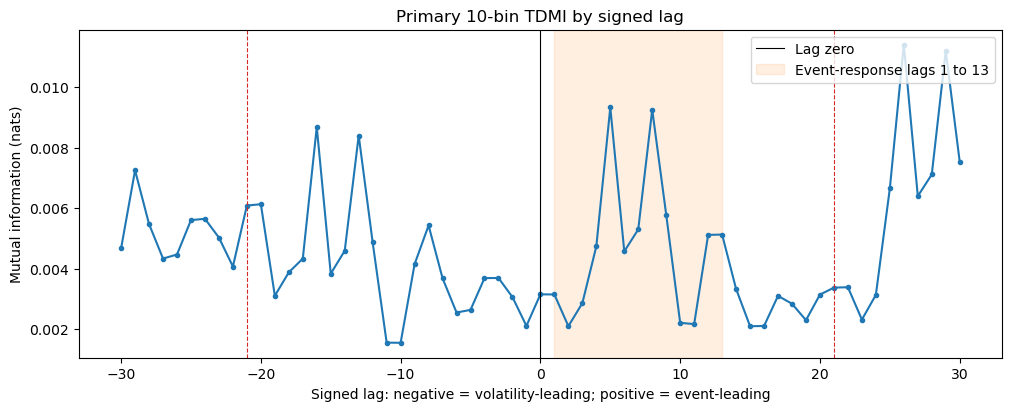

GC summary:
          direction                            lag_label  lag  F-statistic  p-value  log variance ratio
event -> volatility         direct one-step timing check    1    12.094457 0.000550            0.023901
event -> volatility full event-response-window lag order   13     4.190183 0.000001            0.111002
volatility -> event         direct one-step timing check    1     0.156245 0.692806            0.000312
volatility -> event full event-response-window lag order   13     1.163975 0.303267            0.032091
TDMI summary:
 strongest_positive_lag  strongest_positive_mi  strongest_negative_lag  strongest_negative_mi  zero_lag_mi  primary_bins
                     26               0.011406                     -16               0.008683     0.003156            10


In [12]:
fig, axis = plt.subplots(figsize=(10, 4), constrained_layout=True)
axis.plot(tdmi_results['lag'], tdmi_results['mutual_information'], marker='o', markersize=3)
axis.axvline(0, color='black', linewidth=0.8, label='Lag zero')
axis.axvspan(1, 13, color='tab:orange', alpha=0.12, label='Event-response lags 1 to 13')
axis.axvline(21, color='tab:red', linestyle='--', linewidth=0.8)
axis.axvline(-21, color='tab:red', linestyle='--', linewidth=0.8)
axis.set(
    title='Primary 10-bin TDMI by signed lag',
    xlabel='Signed lag: negative = volatility-leading; positive = event-leading',
    ylabel='Mutual information (nats)',
)
axis.legend(loc='upper right')
plt.show()

gc_summary_rows = []
for direction, table in [
    ('event -> volatility', gc_event_to_sigma),
    ('volatility -> event', gc_sigma_to_event),
]:
    for lag_label, lag in [
        ('direct one-step timing check', direct_timing_lag),
        ('full event-response-window lag order', response_window_lag),
    ]:
        row = table.loc[table['lag'].eq(lag)].iloc[0]
        gc_summary_rows.append({
            'direction': direction,
            'lag_label': lag_label,
            'lag': lag,
            'F-statistic': row['f_stat'],
            'p-value': row['p_value'],
            'log variance ratio': row['log_variance_ratio'],
        })
gc_summary_table = pd.DataFrame(gc_summary_rows)
tdmi_summary_table = pd.DataFrame([{
    'strongest_positive_lag': int(positive_tdmi_peak['lag']),
    'strongest_positive_mi': positive_tdmi_peak['mutual_information'],
    'strongest_negative_lag': int(negative_tdmi_peak['lag']),
    'strongest_negative_mi': negative_tdmi_peak['mutual_information'],
    'zero_lag_mi': zero_tdmi['mutual_information'],
    'primary_bins': primary_quantile_bins,
}])
print('GC summary:')
print(gc_summary_table.to_string(index=False))
print('TDMI summary:')
print(tdmi_summary_table.to_string(index=False))

## 17. Interpretation against the known structural graph

The benchmark generator contains E_i -> omega_(i+1) -> sigma_(i+1) and no volatility-to-event edge. A positive-lag TDMI peak or an event-to-volatility GC result is consistent with that graph, not proof of it. Reverse-direction results are retained as a false reverse edge: with deterministic periodic events, they can arise from periodicity-induced predictability rather than a structural sigma -> E effect. Peaks near plus or minus 21 should similarly be interpreted as repeated-cycle structure.

## 18. Validation checks

A small timing-unit test below creates a binary driver and copies it into a later continuous response. The TDMI helper must identify the known positive delay. The limited discretisation-sensitivity check compares 5, 10, and 15 quantile bins; the primary estimator remains 10 bins.

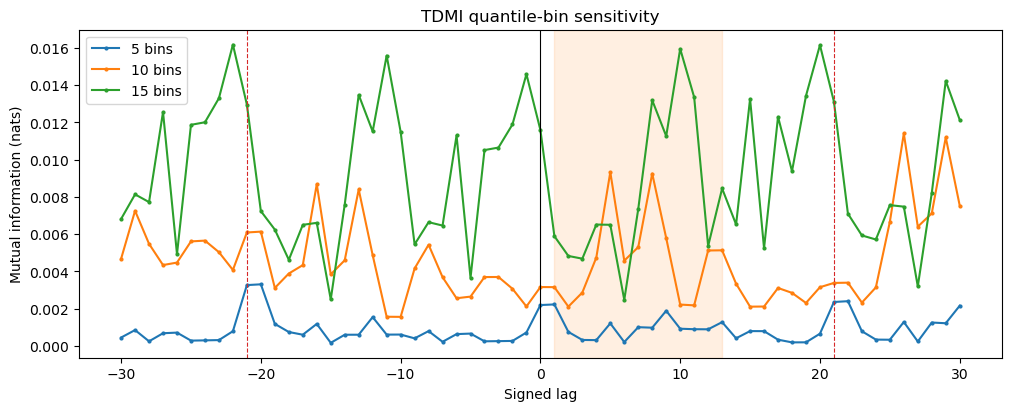

notebook_00_loaded: passed
n_equals_1: passed
event_period_is_21_steps: passed
analysis_alignment: passed
binary_event_and_no_missing_primary_values: passed
historical_gc_lag_matrices: passed
gc_rss_and_residual_df_checks: passed
manual_statsmodels_gc_agreement_p1_and_p13: passed
tdmi_pair_lengths_and_lag_convention: passed
fixed_bin_edges_reused_within_each_curve: passed
tdmi_timing_unit_test: passed
declared_tdmi_method_configuration: passed
simulator_values_unchanged: passed
quantile_bin_sensitivity_completed: passed
Quantile-bin sensitivity peak lags:
 quantile_bins  strongest_positive_lag  strongest_negative_lag  overall_maximum_lag
             5                      22                     -20                  -20
            10                      26                     -16                   26
            15                      20                     -22                  -22
Peak locations identical across bin counts: False
Quantile-bin curve correlations:
quantile_bins      

In [13]:
synthetic_rng = np.random.default_rng(1701)
synthetic_event = synthetic_rng.integers(0, 2, size=120)
synthetic_delay = 4
synthetic_sigma = np.zeros_like(synthetic_event, dtype=float)
synthetic_sigma[synthetic_delay:] = synthetic_event[:-synthetic_delay]
synthetic_sigma += synthetic_rng.normal(scale=1e-4, size=synthetic_sigma.size)
synthetic_bin_edges = make_quantile_bin_edges(synthetic_sigma, primary_quantile_bins)
synthetic_tdmi = pd.DataFrame([
    tdmi_at_lag(synthetic_event, synthetic_sigma, lag, synthetic_bin_edges)
    for lag in range(-10, 11)
])
assert int(synthetic_tdmi.loc[synthetic_tdmi['mutual_information'].idxmax(), 'lag']) == synthetic_delay

sensitivity_rows = []
sensitivity_edges = {
    quantile_bins: make_quantile_bin_edges(sigma_t, quantile_bins)
    for quantile_bins in (5, 10, 15)
}
sensitivity_edge_snapshots = {
    quantile_bins: edges.copy() for quantile_bins, edges in sensitivity_edges.items()
}
for quantile_bins in (5, 10, 15):
    fixed_edges = sensitivity_edges[quantile_bins]
    curve = [tdmi_at_lag(event_t, sigma_t, lag, fixed_edges) for lag in tdmi_lags]
    sensitivity_rows.extend({**row, 'quantile_bins': quantile_bins} for row in curve)
sensitivity_table = pd.DataFrame(sensitivity_rows)

fig, axis = plt.subplots(figsize=(10, 4), constrained_layout=True)
for quantile_bins, subset in sensitivity_table.groupby('quantile_bins'):
    axis.plot(subset['lag'], subset['mutual_information'], marker='o', markersize=2, label=f'{quantile_bins} bins')
axis.axvline(0, color='black', linewidth=0.8)
axis.axvspan(1, 13, color='tab:orange', alpha=0.12)
axis.axvline(21, color='tab:red', linestyle='--', linewidth=0.8)
axis.axvline(-21, color='tab:red', linestyle='--', linewidth=0.8)
axis.set(title='TDMI quantile-bin sensitivity', xlabel='Signed lag', ylabel='Mutual information (nats)')
axis.legend()
plt.show()

sensitivity_peak_rows = []
for quantile_bins, subset in sensitivity_table.groupby('quantile_bins'):
    positive_peak = subset.loc[subset['lag'].gt(0)].nlargest(1, 'mutual_information').iloc[0]
    negative_peak = subset.loc[subset['lag'].lt(0)].nlargest(1, 'mutual_information').iloc[0]
    overall_peak = subset.nlargest(1, 'mutual_information').iloc[0]
    sensitivity_peak_rows.append({
        'quantile_bins': quantile_bins,
        'strongest_positive_lag': int(positive_peak['lag']),
        'strongest_negative_lag': int(negative_peak['lag']),
        'overall_maximum_lag': int(overall_peak['lag']),
    })
sensitivity_peak_table = pd.DataFrame(sensitivity_peak_rows)
sensitivity_pivot = sensitivity_table.pivot(index='lag', columns='quantile_bins', values='mutual_information')
sensitivity_correlations = sensitivity_pivot.corr()
for quantile_bins, edges in sensitivity_edges.items():
    np.testing.assert_array_equal(edges, sensitivity_edge_snapshots[quantile_bins])
peak_locations_match = bool(
    sensitivity_peak_table[['strongest_positive_lag', 'strongest_negative_lag', 'overall_maximum_lag']]
    .nunique().eq(1).all()
)
assert tdmi_method['estimator'] == 'direct_contingency_table'
assert tdmi_method['volatility_discretisation'] == 'fixed_quantile_bins'
assert tdmi_method['uses_circular_shift'] is False
assert tdmi_method['uses_permutation'] is False
assert tdmi_method['uses_sklearn_mi'] is False
assert len(gc_crosscheck_table) == 4
assert (gc_event_to_sigma['rss_unrestricted'] <= gc_event_to_sigma['rss_restricted'] + 1e-10).all()
assert (gc_sigma_to_event['rss_unrestricted'] <= gc_sigma_to_event['rss_restricted'] + 1e-10).all()
assert (gc_event_to_sigma['residual_df'] > 0).all()
assert (gc_sigma_to_event['residual_df'] > 0).all()
pd.testing.assert_frame_equal(states, states_snapshot)
pd.testing.assert_frame_equal(transitions, transitions_snapshot)

validation_summary = {
    'notebook_00_loaded': 'passed',
    'n_equals_1': 'passed',
    'event_period_is_21_steps': 'passed',
    'analysis_alignment': 'passed',
    'binary_event_and_no_missing_primary_values': 'passed',
    'historical_gc_lag_matrices': 'passed',
    'gc_rss_and_residual_df_checks': 'passed',
    'manual_statsmodels_gc_agreement_p1_and_p13': 'passed',
    'tdmi_pair_lengths_and_lag_convention': 'passed',
    'fixed_bin_edges_reused_within_each_curve': 'passed',
    'tdmi_timing_unit_test': 'passed',
    'declared_tdmi_method_configuration': 'passed',
    'simulator_values_unchanged': 'passed',
    'quantile_bin_sensitivity_completed': 'passed',
}
for check, outcome in validation_summary.items():
    print(f'{check}: {outcome}')
print('Quantile-bin sensitivity peak lags:')
print(sensitivity_peak_table.to_string(index=False))
print(f'Peak locations identical across bin counts: {peak_locations_match}')
print('Quantile-bin curve correlations:')
print(sensitivity_correlations.to_string())

## 19. Final interpretation

The known structural graph is E_i -> omega_(i+1) -> sigma_(i+1). At p = 1, the event indicator Granger-predicts volatility (F = 12.094457, p = 0.000550, log variance ratio = 0.023901), whereas volatility does not Granger-predict the event indicator (F = 0.156245, p = 0.692806, log variance ratio = 0.000312). This is a clean one-step predictive-direction result, not proof of physical causality.

At p = 13, event -> volatility also rejects the nested-regression null (F = 4.190183, p approximately 0.000001, log variance ratio = 0.111002), while the false reverse edge remains insignificant (F = 1.163975, p = 0.303267, log variance ratio = 0.032091). Here p = 13 is the full event-response-window lag order; it is not a causal delay.

With 10 fixed full-series volatility bins, the largest observed positive-lag TDMI is 0.011406 nats at event-leading lag +26, the largest observed negative-lag TDMI is 0.008683 nats at volatility-leading lag -16, and contemporaneous TDMI is 0.003156 nats. These are descriptive sample maxima without formal p-values and are not estimates of a true causal delay.

The strongest positive, strongest negative, and overall maximum lags are respectively (+22, -20, -20) for 5 bins, (+26, -16, +26) for 10 bins, and (+20, -22, -22) for 15 bins. The curves also have weak pairwise correlations. The TDMI direction and delay are therefore not robust to bin choice in this sample.

GC asks whether lagged driver values improve linear prediction beyond the target's own history. TDMI measures general lagged dependence and does not condition on that history, so the two methods do not answer the same question. Their agreement or disagreement is informative but does not establish structural causality.